# 상위20% 위축 예측 — 모델 학습 (로지스틱 회귀, 1차)

**전제**
- 최종 feature: `KID_CATEGORY_DESC_encoded` 제외 (VIF 26.7로 심각, HOUSEHOLD_SIZE_DESC와 중복 정보)
- 표본: 499가구 (위축=1: 223명, 유지=0: 276명)
- 검증 방식: StratifiedKFold 5-fold (라벨 비율 유지)
- 평가지표: PR-AUC, Recall, ROC-AUC (정확도는 참고용으로만 병기)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42


## 1. 최종 feature 확정 및 저장

VIF에서 심각했던 `KID_CATEGORY_DESC_encoded`를 제거한 최종 버전을 별도 파일로 저장한다.


In [2]:
encoded_table = pd.read_csv("h4_shrink_feature_table_encoded.csv", index_col=0)
encoded_table.index.name = "HOUSEHOLD_KEY"

feature_cols_final = [c for c in encoded_table.columns
                       if c not in ("label_shrink", "KID_CATEGORY_DESC_encoded")]

final_table = encoded_table[feature_cols_final + ["label_shrink"]].copy()
final_table.to_csv("h4_shrink_feature_table_final.csv")

print(f"최종 feature 개수: {len(feature_cols_final)}")
print(f"최종 테이블 shape: {final_table.shape}")
print(f"\n라벨 분포\n{final_table['label_shrink'].value_counts()}")
print(list(feature_cols_final))


최종 feature 개수: 18
최종 테이블 shape: (499, 19)

라벨 분포
label_shrink
0    276
1    223
Name: count, dtype: int64
['sales_early', 'n_baskets', 'avg_items_per_basket', 'category_diversity', 'exposure_ratio', 'has_demo', 'AGE_DESC_encoded', 'INCOME_DESC_encoded', 'HOUSEHOLD_SIZE_DESC_encoded', 'HOMEOWNER_DESC_Probable Owner', 'HOMEOWNER_DESC_Probable Renter', 'HOMEOWNER_DESC_Renter', 'HOMEOWNER_DESC_Unknown', 'HH_COMP_DESC_1 Adult Kids', 'HH_COMP_DESC_2 Adults Kids', 'HH_COMP_DESC_Single Female', 'HH_COMP_DESC_Single Male', 'HH_COMP_DESC_Unknown']


## 2. X, y 분리 및 스케일링 대상 지정

연속형 성격의 feature(수치형 5개 + 순서형 인코딩 3개)만 표준화하고,
이미 0/1인 이진 변수(has_demo, 원-핫 더미)는 스케일링하지 않는다.


In [3]:
X = final_table[feature_cols_final]
y = final_table["label_shrink"]

numeric_scale_cols = [
    "sales_early", "n_baskets", "avg_items_per_basket", "category_diversity", "exposure_ratio",
    "AGE_DESC_encoded", "INCOME_DESC_encoded", "HOUSEHOLD_SIZE_DESC_encoded",
]
binary_cols = [c for c in feature_cols_final if c not in numeric_scale_cols]

print(f"표준화 대상({len(numeric_scale_cols)}개): {numeric_scale_cols}")
print(f"\n그대로 사용({len(binary_cols)}개): {binary_cols}")


표준화 대상(8개): ['sales_early', 'n_baskets', 'avg_items_per_basket', 'category_diversity', 'exposure_ratio', 'AGE_DESC_encoded', 'INCOME_DESC_encoded', 'HOUSEHOLD_SIZE_DESC_encoded']

그대로 사용(10개): ['has_demo', 'HOMEOWNER_DESC_Probable Owner', 'HOMEOWNER_DESC_Probable Renter', 'HOMEOWNER_DESC_Renter', 'HOMEOWNER_DESC_Unknown', 'HH_COMP_DESC_1 Adult Kids', 'HH_COMP_DESC_2 Adults Kids', 'HH_COMP_DESC_Single Female', 'HH_COMP_DESC_Single Male', 'HH_COMP_DESC_Unknown']


## 3. 전처리 + 모델 파이프라인 구성

ColumnTransformer로 스케일링 대상만 표준화하고, 로지스틱 회귀(L2 정규화)에 연결.


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), numeric_scale_cols),
        ("passthrough", "passthrough", binary_cols),
    ]
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 4. 교차검증 성능 평가 (PR-AUC, Recall, ROC-AUC)

In [5]:
scoring = {
    "pr_auc": "average_precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",  # 참고용
}

cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=False)

results_summary = pd.DataFrame({
    "metric": list(scoring.keys()),
    "mean": [cv_results[f"test_{k}"].mean() for k in scoring],
    "std": [cv_results[f"test_{k}"].std() for k in scoring],
})
print("5-fold 교차검증 결과 (평균 ± 표준편차)")
print(results_summary)


c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Li

5-fold 교차검증 결과 (평균 ± 표준편차)
     metric      mean       std
0    pr_auc  0.674204  0.056361
1    recall  0.614646  0.080202
2   roc_auc  0.734162  0.050845
3  accuracy  0.677152  0.058866


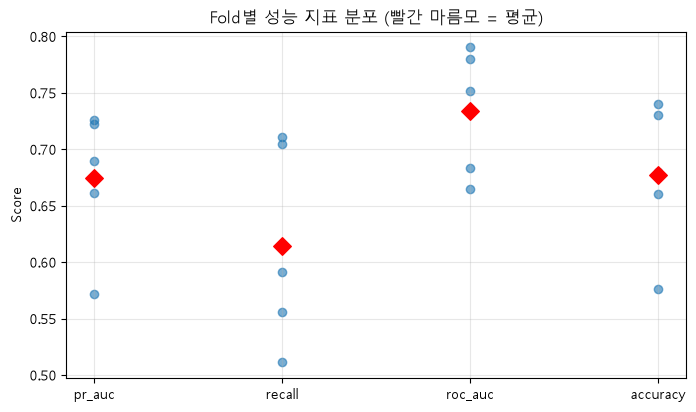

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i, metric in enumerate(scoring.keys()):
    ax.scatter([i]*5, cv_results[f"test_{metric}"], alpha=0.6, color='C0')
    ax.scatter(i, cv_results[f"test_{metric}"].mean(), color='red', marker='D', s=80, zorder=5)
ax.set_xticks(range(len(scoring)))
ax.set_xticklabels(list(scoring.keys()))
ax.set_title("Fold별 성능 지표 분포 (빨간 마름모 = 평균)")
ax.set_ylabel("Score")
ax.grid(alpha=0.3)
plt.show()


## 5. Out-of-fold 예측 기반 분류 리포트 + 혼동행렬

각 fold에서 학습된 모델이 그 fold의 검증셋을 예측한 값을 모아(중복 없이) 전체적인 분류 성능을 확인.


In [7]:
y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

print("분류 리포트 (0=유지, 1=위축)")
print(classification_report(y, y_pred, target_names=["유지(0)", "위축(1)"]))

cm = confusion_matrix(y, y_pred)
print("혼동행렬")
print(pd.DataFrame(cm, index=["실제 유지", "실제 위축"], columns=["예측 유지", "예측 위축"]))


c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Li

분류 리포트 (0=유지, 1=위축)
              precision    recall  f1-score   support

       유지(0)       0.70      0.73      0.71       276
       위축(1)       0.65      0.61      0.63       223

    accuracy                           0.68       499
   macro avg       0.67      0.67      0.67       499
weighted avg       0.68      0.68      0.68       499

혼동행렬
       예측 유지  예측 위축
실제 유지    201     75
실제 위축     86    137


## 6. 전체 데이터로 최종 학습 — 계수 해석용

**주의**: 위 4~5번은 성능 "평가"를 위한 것이고(각 예측이 학습에 안 쓰인 fold에서 나옴),
아래는 계수 "해석"을 위해 전체 데이터로 다시 학습한 별도 모델이다. 성능 지표를 여기서 다시 보면 안 됨(과적합된 값).


In [8]:
model.fit(X, y)

coef = model.named_steps["clf"].coef_[0]
feature_names = numeric_scale_cols + binary_cols  # ColumnTransformer 출력 순서와 동일

coef_table = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef,
    "odds_ratio": np.exp(coef),
}).sort_values("odds_ratio", ascending=False)

print("계수 및 오즈비 (odds_ratio > 1 → 위축 가능성 높임, < 1 → 위축 가능성 낮춤)")
print(coef_table)


계수 및 오즈비 (odds_ratio > 1 → 위축 가능성 높임, < 1 → 위축 가능성 낮춤)
                           feature  coefficient  odds_ratio
9    HOMEOWNER_DESC_Probable Owner     0.422954    1.526464
12          HOMEOWNER_DESC_Unknown     0.371489    1.449892
1                        n_baskets     0.255164    1.290674
7      HOUSEHOLD_SIZE_DESC_encoded     0.137039    1.146873
2             avg_items_per_basket     0.046075    1.047153
11           HOMEOWNER_DESC_Renter    -0.026243    0.974098
4                   exposure_ratio    -0.036752    0.963915
5                 AGE_DESC_encoded    -0.072125    0.930415
3               category_diversity    -0.303821    0.737993
6              INCOME_DESC_encoded    -0.312111    0.731900
16        HH_COMP_DESC_Single Male    -0.330557    0.718524
0                      sales_early    -0.443316    0.641904
15      HH_COMP_DESC_Single Female    -0.597559    0.550153
10  HOMEOWNER_DESC_Probable Renter    -0.606003    0.545527
17            HH_COMP_DESC_Unknown    -0.6095

c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


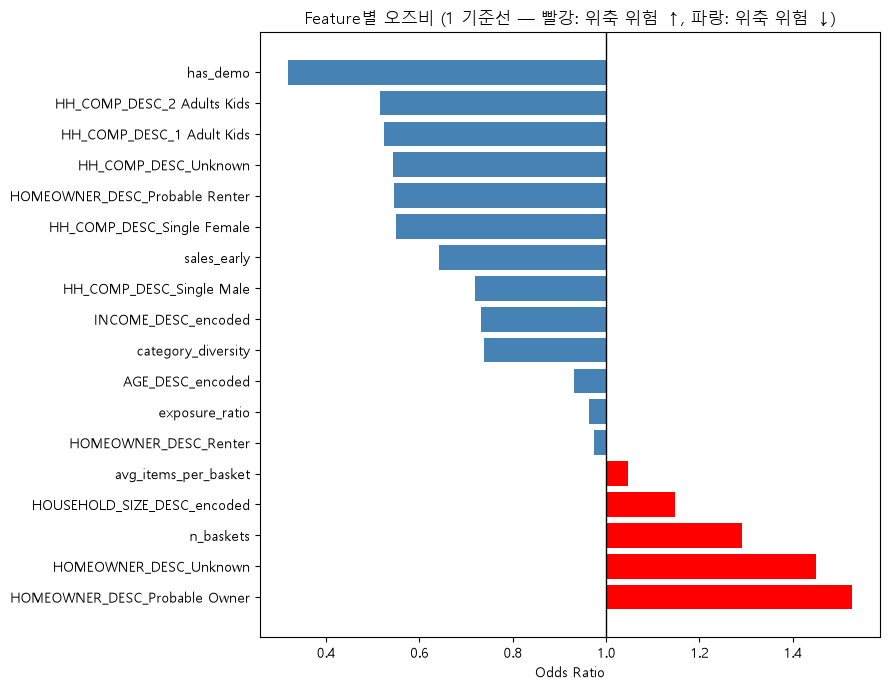

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['red' if v > 1 else 'steelblue' for v in coef_table["odds_ratio"]]
ax.barh(coef_table["feature"], coef_table["odds_ratio"] - 1, left=1, color=colors)
ax.axvline(1, color='black', linewidth=1)
ax.set_xlabel("Odds Ratio")
ax.set_title("Feature별 오즈비 (1 기준선 — 빨강: 위축 위험 ↑, 파랑: 위축 위험 ↓)")
plt.tight_layout()
plt.show()


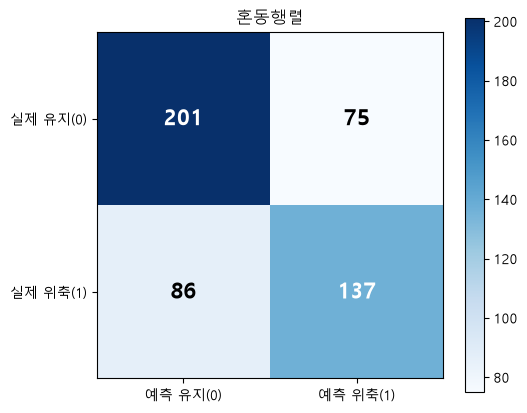

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")

labels_display = ["유지(0)", "위축(1)"]
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([f"예측 {l}" for l in labels_display])
ax.set_yticklabels([f"실제 {l}" for l in labels_display])

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}", ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontsize=16, fontweight="bold")

ax.set_title("혼동행렬")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 7. 해석 가이드

- **오즈비 > 1인 feature**: 값이 클수록(또는 해당 카테고리에 속할수록) 위축 가능성이 높아짐
- **오즈비 < 1인 feature**: 값이 클수록 위축 가능성이 낮아짐 (유지에 유리)
- 지난번 그룹별 기초통계에서 본 신호(sales_early·category_diversity가 유지 그룹에서 높음, exposure_ratio는 반대)와
  계수 방향이 일치하는지 비교 — 일치하면 통계적 탐색과 모델 결과가 서로 교차검증된 것
- 다음 단계: 랜덤포레스트+SHAP으로 비선형 관계·상호작용까지 확인해서 로지스틱 결과와 비교


In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import permutation_test_score, learning_curve

# ---- 1) Permutation Test: 우연히 나올 수 있는 성능인지 ----
score, perm_scores, pvalue = permutation_test_score(
    model, X, y, cv=cv, scoring="average_precision",
    n_permutations=1000, random_state=RANDOM_STATE, n_jobs=-1
)

print(f"실제 PR-AUC: {score:.4f}")
print(f"라벨을 무작위로 섞었을 때 PR-AUC 분포: 평균={perm_scores.mean():.4f}, 표준편차={perm_scores.std():.4f}")
print(f"p-value: {pvalue:.4f}")
print(f"→ {'우연이 아니라 유의미한 학습' if pvalue < 0.05 else '우연과 통계적으로 구분 안 됨 — 주의 필요'}")

c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\spide\anaconda3\envs\myenv\Li

실제 PR-AUC: 0.6742
라벨을 무작위로 섞었을 때 PR-AUC 분포: 평균=0.4730, 표준편차=0.0305
p-value: 0.0010
→ 우연이 아니라 유의미한 학습


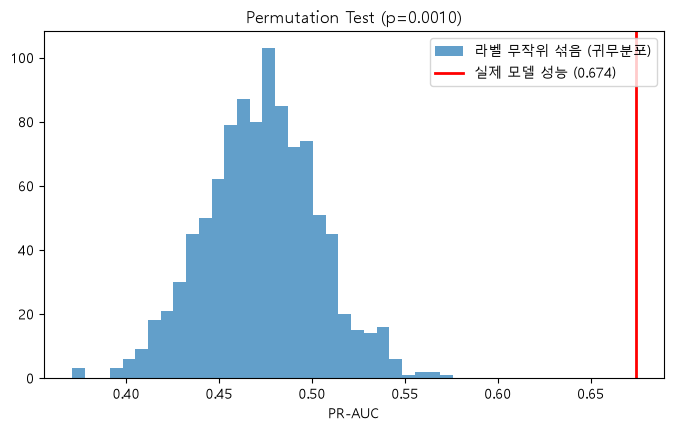

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(perm_scores, bins=30, alpha=0.7, label="라벨 무작위 섞음 (귀무분포)")
ax.axvline(score, color='red', linewidth=2, label=f"실제 모델 성능 ({score:.3f})")
ax.set_xlabel("PR-AUC")
ax.set_title(f"Permutation Test (p={pvalue:.4f})")
ax.legend()
plt.show()

In [16]:
# ---- 2) Dummy Classifier와 비교 ----
dummy_stratified = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy_scores = cross_validate(dummy_stratified, X, y, cv=cv, scoring=scoring)

print("Dummy(전략=stratified, 라벨 비율만 따라 무작위 예측) 기준선")
for k in scoring:
    print(f"  {k}: {dummy_scores[f'test_{k}'].mean():.4f}")

print(f"\n실제 로지스틱 모델 대비 개선폭 (PR-AUC): "
      f"{score - dummy_scores['test_pr_auc'].mean():+.4f}")

Dummy(전략=stratified, 라벨 비율만 따라 무작위 예측) 기준선
  pr_auc: 0.4452
  recall: 0.4033
  roc_auc: 0.4934
  accuracy: 0.5030

실제 로지스틱 모델 대비 개선폭 (PR-AUC): +0.2290


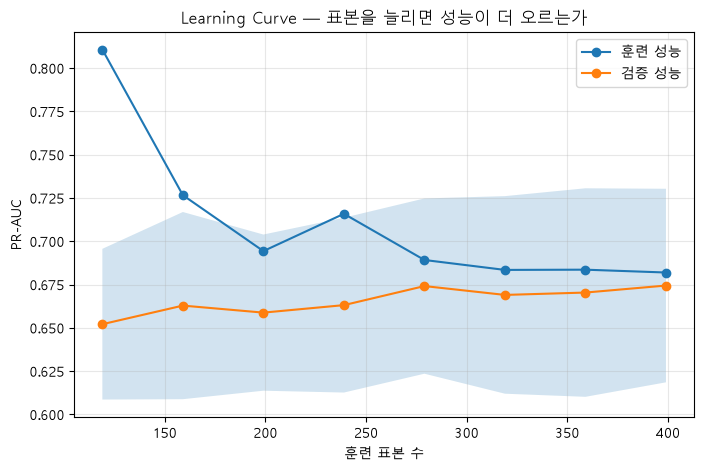

훈련 성능과 검증 성능의 최종 격차: 0.0075
→ 격차가 크면 과적합(훈련은 잘 맞추는데 새 데이터엔 약함), 격차가 작으면 과적합은 아님


In [15]:
# ---- 3) Learning Curve: 표본이 더 있으면 나아지는가 ----
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=cv, scoring="average_precision",
    train_sizes=np.linspace(0.3, 1.0, 8), random_state=RANDOM_STATE, n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="훈련 성능")
ax.plot(train_sizes, val_scores.mean(axis=1), marker='o', label="검증 성능")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_xlabel("훈련 표본 수")
ax.set_ylabel("PR-AUC")
ax.set_title("Learning Curve — 표본을 늘리면 성능이 더 오르는가")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"훈련 성능과 검증 성능의 최종 격차: {train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]:.4f}")
print("→ 격차가 크면 과적합(훈련은 잘 맞추는데 새 데이터엔 약함), 격차가 작으면 과적합은 아님")

## 로지스틱 회귀모델 임계값 조정 후 recall과 precision 변화 관찰

In [17]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y, y_proba)

# precision_recall_curve는 thresholds가 precisions/recalls보다 1개 적게 나옴 (마지막 지점 보정)
precisions = precisions[:-1]
recalls = recalls[:-1]

pr_table = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions,
    "recall": recalls,
})
pr_table["f1"] = 2 * pr_table["precision"] * pr_table["recall"] / (pr_table["precision"] + pr_table["recall"])

c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


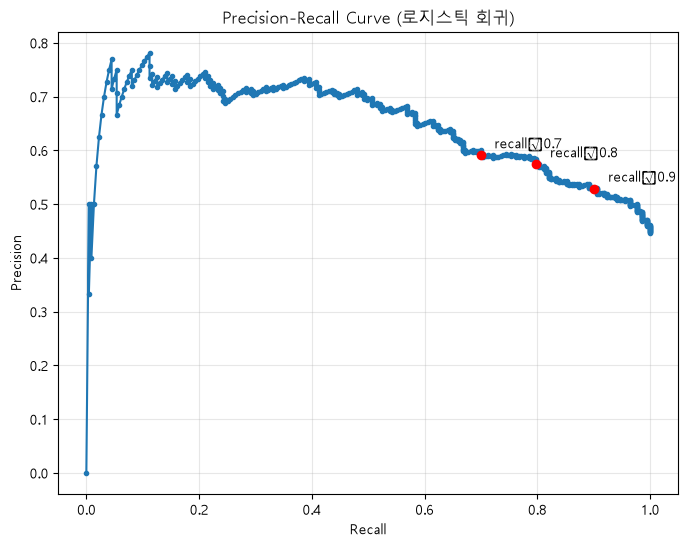

In [18]:
# 전체 곡선 시각화 — recall을 얼마나 올리려면 precision을 얼마나 희생해야 하는지 한눈에
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recalls, precisions, marker='.')
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve (로지스틱 회귀)")
ax.grid(alpha=0.3)

for target_recall in [0.7, 0.8, 0.9]:
    idx = (pr_table["recall"] - target_recall).abs().idxmin()
    ax.annotate(f"recall≈{target_recall}", (recalls[idx], precisions[idx]),
                textcoords="offset points", xytext=(10, 5))
    ax.scatter(recalls[idx], precisions[idx], color='red', zorder=5)

plt.show()

In [19]:
# 임계값별 표 — 0.05 간격으로 촘촘히 보기
threshold_grid = np.arange(0.1, 0.9, 0.05)
rows = []
for t in threshold_grid:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": round(t, 2),
        "precision": precisions[np.argmin(np.abs(thresholds - t))] if len(thresholds) > 0 else np.nan,
        "recall": ((y_pred_t == 1) & (y == 1)).sum() / (y == 1).sum(),
        "precision_actual": ((y_pred_t == 1) & (y == 1)).sum() / max((y_pred_t == 1).sum(), 1),
        "f1": f1_score(y, y_pred_t),
        "n_predicted_at_risk": (y_pred_t == 1).sum(),
    })

threshold_table = pd.DataFrame(rows)
threshold_table

,threshold,precision,recall,precision_actual,f1,n_predicted_at_risk
0,0.10,0.469345,0.995516,0.469345,0.637931,473
1,0.15,0.486607,0.977578,0.486607,0.649776,448
2,0.20,0.508274,0.964126,0.508274,0.665635,423
3,0.25,0.521964,0.905830,0.523316,0.663383,386
4,0.30,0.538244,0.852018,0.539773,0.660870,352
5,0.35,0.571885,0.802691,0.571885,0.667910,313
6,0.40,0.591912,0.721973,0.591912,0.650505,272
7,0.45,0.608163,0.668161,0.608163,0.636752,245
8,0.50,0.647887,0.614350,0.646226,0.629885,212
9,0.55,0.674033,0.547085,0.674033,0.603960,181


In [20]:
# 목표: Recall 0.8 이상을 만족하는 가장 높은(=precision을 가장 덜 희생하는) 임계값 찾기
candidates = threshold_table[threshold_table["recall"] >= 0.8]
if len(candidates) > 0:
    best_row = candidates.sort_values("threshold", ascending=False).iloc[0]
    print("Recall ≥ 0.8을 만족하는 임계값 중 가장 높은(precision 손실 최소) 지점")
    print(best_row)
else:
    print("Recall 0.8 이상을 만족하는 임계값이 그리드 안에 없음 — 임계값을 더 낮춰서 재탐색 필요")

Recall ≥ 0.8을 만족하는 임계값 중 가장 높은(precision 손실 최소) 지점
threshold                0.350000
precision                0.571885
recall                   0.802691
precision_actual         0.571885
f1                       0.667910
n_predicted_at_risk    313.000000
Name: 5, dtype: float64


In [21]:
# 기본값(0.5)과 조정된 임계값 비교
default_recall = threshold_table.loc[threshold_table["threshold"] == 0.50, "recall"].values[0]
print(f"기본 임계값(0.5) recall: {default_recall:.3f}")
print(f"조정된 임계값({best_row['threshold']:.2f}) recall: {best_row['recall']:.3f}")
print(f"이때 precision 변화: {best_row['precision_actual']:.3f}")
print(f"위험군으로 분류되는 가구 수: {best_row['n_predicted_at_risk']:.0f}명 (전체 499명 중)")

기본 임계값(0.5) recall: 0.614
조정된 임계값(0.35) recall: 0.803
이때 precision 변화: 0.572
위험군으로 분류되는 가구 수: 313명 (전체 499명 중)


In [22]:
def risk_tier(prob):
    if prob >= 0.6:
        return "고위험 (즉시 대응)"
    elif prob >= 0.35:
        return "중위험 (모니터링+저비용 캠페인)"
    else:
        return "저위험"

risk_segments = pd.Series([risk_tier(p) for p in y_proba], index=y.index)
segment_summary = pd.DataFrame({"risk_tier": risk_segments, "actual_label": y})

print(segment_summary["risk_tier"].value_counts())
print("\n세그먼트별 실제 위축 비율 (모델이 잘 분리했는지 확인)")
print(segment_summary.groupby("risk_tier")["actual_label"].mean())

risk_tier
저위험                   186
중위험 (모니터링+저비용 캠페인)    163
고위험 (즉시 대응)           150
Name: count, dtype: int64

세그먼트별 실제 위축 비율 (모델이 잘 분리했는지 확인)
risk_tier
고위험 (즉시 대응)           0.713333
저위험                   0.236559
중위험 (모니터링+저비용 캠페인)    0.441718
Name: actual_label, dtype: float64
